<a href="https://colab.research.google.com/github/Krishnapriyathankamaninair/Casestudy-on-Python-Basics/blob/main/AI_DRIVEN_EMPLOYEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import joblib
import os
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import chardet

file_path = "/employee_attrition_dataset_10000.csv"

with open(file_path, "rb") as f:
    result = chardet.detect(f.read(100000))

print(result)

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


In [26]:
#reading dataset
data = pd.read_csv(file_path, encoding=result['encoding'])
data.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [27]:
print("\n" + "="*70)
print("DATA UNDERSTANDING")
print("="*70)

print("\nDataset Shape:")
print(data.shape)

print("\nFirst 5 Records:")
display(data.head())

print("\nLast 5 Records:")
display(data.tail())

print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nDataset Information:")
data.info()


DATA UNDERSTANDING

Dataset Shape:
(10000, 26)

First 5 Records:


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No



Last 5 Records:


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
9995,9996,22,Female,Divorced,Marketing,Manager,5,4276,27,17,...,Yes,3,36,3,4,2,3,18,2,No
9996,9997,35,Female,Divorced,Marketing,Executive,3,10327,60,19,...,No,5,59,4,4,3,4,31,1,No
9997,9998,23,Male,Divorced,IT,Manager,3,12592,68,10,...,Yes,4,54,10,4,4,2,12,1,Yes
9998,9999,42,Female,Single,Marketing,Manager,3,9287,26,18,...,Yes,9,51,16,3,2,2,18,3,No
9999,10000,39,Female,Divorced,Finance,Executive,2,7225,54,16,...,Yes,4,51,6,4,1,1,6,2,Yes



Column Names:
['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department', 'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked', 'Attrition']

Data Types:
Employee_ID                       int64
Age                               int64
Gender                           object
Marital_Status                   object
Department                       object
Job_Role                         object
Job_Level                         int64
Monthly_Income                    int64
Hourly_Rate                       int64
Years_at_Company                  int64
Years_in_Current_Role             int64
Years_Since_Last_Pro

In [28]:
#MISSING VALUES

print("\n" + "="*70)
print("MISSING VALUE ANALYSIS")
print("="*70)

missing_values = data.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(data)) * 100
})

missing_table = missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_table)



MISSING VALUE ANALYSIS


,Missing Values,Percentage
Employee_ID,0,0.0
Age,0,0.0
Gender,0,0.0
Marital_Status,0,0.0
Department,0,0.0
Job_Role,0,0.0
Job_Level,0,0.0
Monthly_Income,0,0.0
Hourly_Rate,0,0.0
Years_at_Company,0,0.0


In [29]:
 #DUPLICATE CHECKING


print("\n" + "="*70)
print("DUPLICATE CHECKING")
print("="*70)

duplicate_count = data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = data.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")


DUPLICATE CHECKING
Number of duplicate rows: 0
No duplicate rows found.


In [30]:
# 7. TARGET VARIABLE CHECK
print("\n" + "="*70)
print("TARGET VARIABLE")
print("="*70)

if "Attrition" not in data.columns:
    raise ValueError(
        "The dataset does not contain an 'Attrition' column."
    )

print(data["Attrition"].value_counts())

print("\nPercentage Distribution:")
print(
    data["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)




TARGET VARIABLE
Attrition
No     8003
Yes    1997
Name: count, dtype: int64

Percentage Distribution:
Attrition
No     80.03
Yes    19.97
Name: proportion, dtype: float64


In [31]:
#BASIC DATA CLEANING
columns_to_remove = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

existing_remove_columns = [
    col for col in columns_to_remove
    if col in data.columns
]

if len(existing_remove_columns) > 0:
    df = data.drop(columns=existing_remove_columns)

print("\nRemoved non-predictive columns:")
print(existing_remove_columns)


Removed non-predictive columns:
[]



EXPLORATORY DATA ANALYSIS


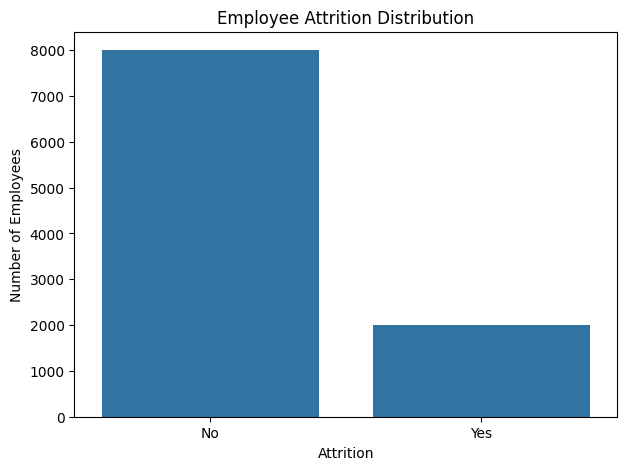

In [32]:
#EXPLORATORY DATA ANALYSIS
df=data
print("\n" + "="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()


Attrition percentage by department:


Attrition,No,Yes
Department,,
Finance,79.145729,20.854271
HR,80.491551,19.508449
IT,79.645094,20.354906
Marketing,80.637600,19.362400
Sales,80.179283,19.820717


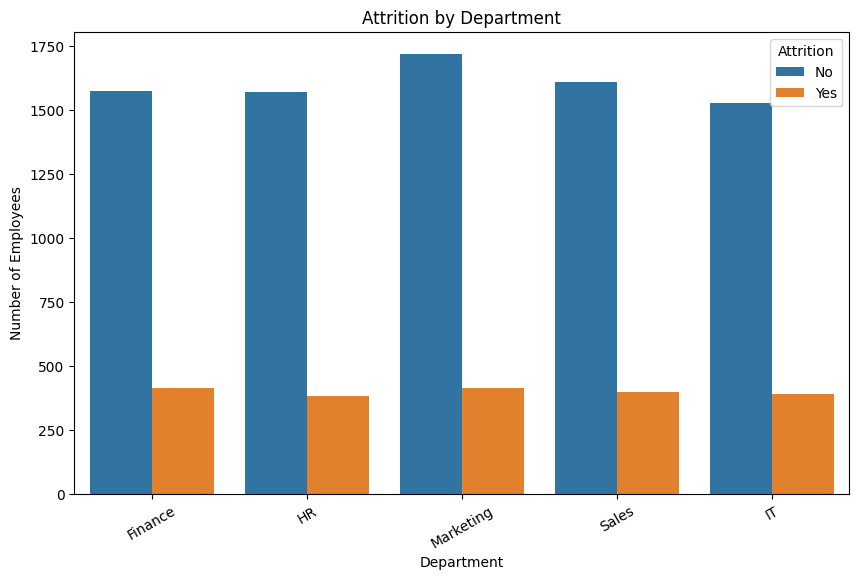

In [33]:
#ATTRITION BY DEPARTMENT



if "Department" in df.columns:

    department_attrition = pd.crosstab(
        df["Department"],
        df["Attrition"],
        normalize="index"
    ) * 100

    print("\nAttrition percentage by department:")
    display(department_attrition)

    plt.figure(figsize=(10,6))

    sns.countplot(
        data=df,
        x="Department",
        hue="Attrition"
    )

    plt.title("Attrition by Department")
    plt.xticks(rotation=30)
    plt.xlabel("Department")
    plt.ylabel("Number of Employees")

    plt.show()


CORRELATION ANALYSIS


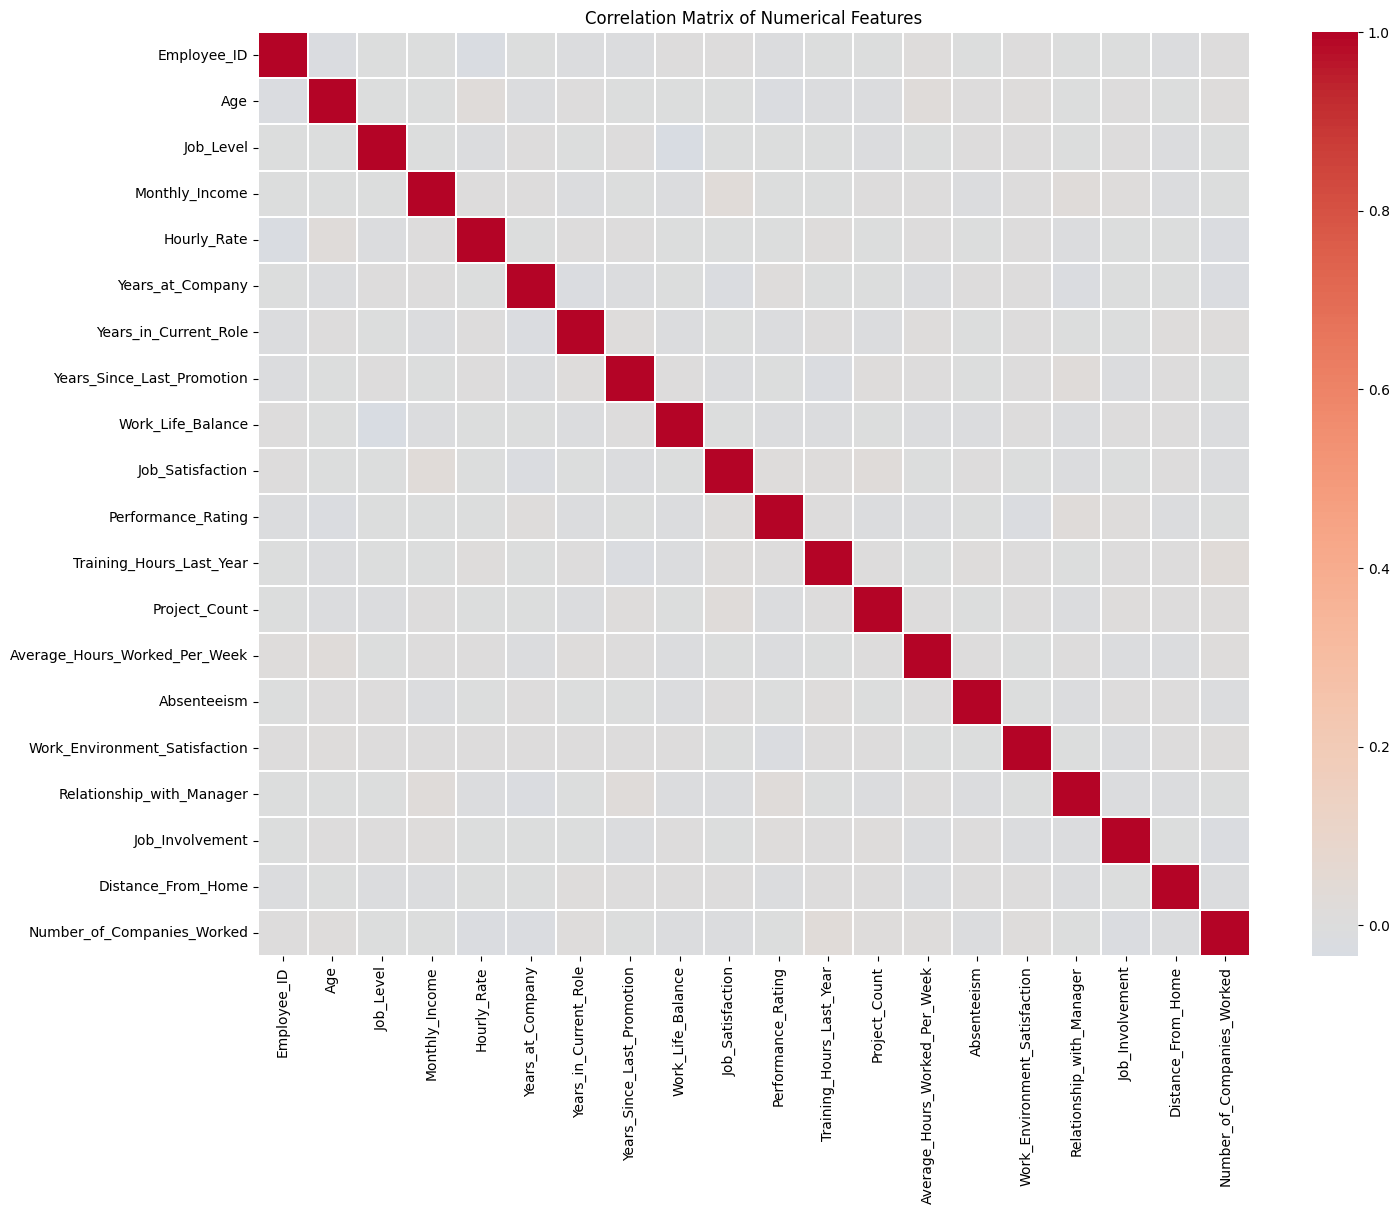


TARGET ENCODING
  Attrition  Attrition_Encoded
0        No                  0
1        No                  0
2       Yes                  1
3        No                  0
4        No                  0

Target distribution:
Attrition_Encoded
0    8003
1    1997
Name: count, dtype: int64

Numerical Features:
['Employee_ID', 'Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']

Categorical Features:
['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']

Training samples: 8000
Testing samples: 2000

MODEL TRAINING

Training: Logistic Regression

Training: Decision Tree

Training: Random Forest

MODEL PERFORMANCE COMPA

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5140,0.201873,0.486216,0.285294,0.507803
1,Decision Tree,0.5705,0.187500,0.345865,0.243172,0.473719
2,Random Forest,0.7995,0.375000,0.007519,0.014742,0.494063




Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.80      0.52      0.63      1601
        Left       0.20      0.49      0.29       399

    accuracy                           0.51      2000
   macro avg       0.50      0.50      0.46      2000
weighted avg       0.68      0.51      0.56      2000



Decision Tree
              precision    recall  f1-score   support

      Stayed       0.79      0.63      0.70      1601
        Left       0.19      0.35      0.24       399

    accuracy                           0.57      2000
   macro avg       0.49      0.49      0.47      2000
weighted avg       0.67      0.57      0.61      2000



Random Forest
              precision    recall  f1-score   support

      Stayed       0.80      1.00      0.89      1601
        Left       0.38      0.01      0.01       399

    accuracy                           0.80      2000
   macro avg       0.59      0.50      0.45      2000
weighted avg       0

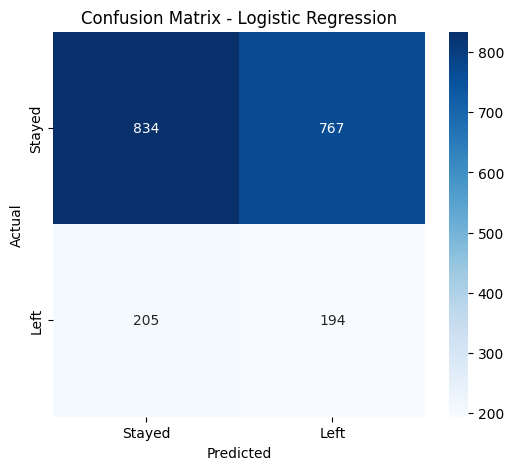

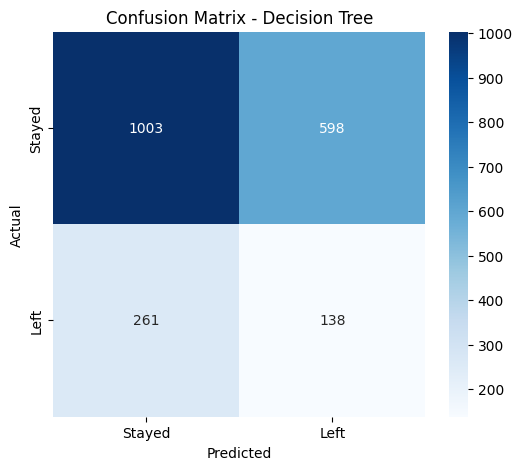

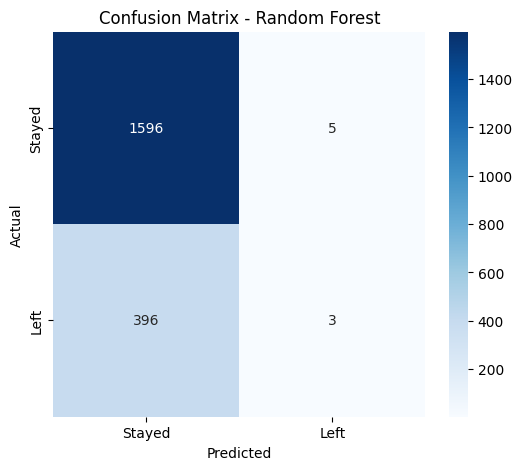

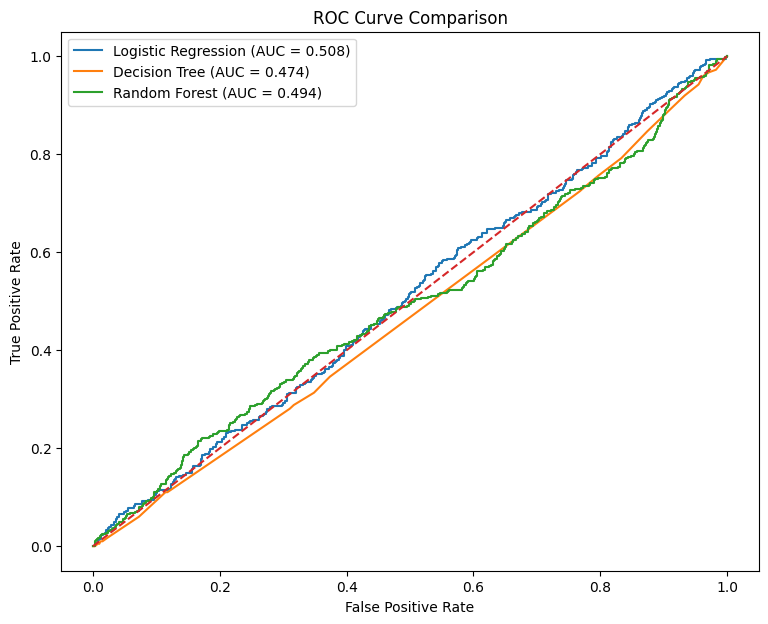


BEST MODEL
Best model based on F1-score:
Logistic Regression

FEATURE IMPORTANCE

Most influential Logistic Regression features:


,Feature,Coefficient,Absolute_Coefficient
33,cat__Job_Role_Manager,-0.075025,0.075025
25,cat__Department_Finance,0.068209,0.068209
28,cat__Department_Marketing,-0.050503,0.050503
19,num__Number_of_Companies_Worked,-0.048497,0.048497
2,num__Job_Level,0.045808,0.045808
17,num__Job_Involvement,0.044328,0.044328
31,cat__Job_Role_Assistant,0.041967,0.041967
18,num__Distance_From_Home,0.041053,0.041053
22,cat__Marital_Status_Divorced,0.039429,0.039429
23,cat__Marital_Status_Married,-0.034519,0.034519



HIGH-RISK EMPLOYEE IDENTIFICATION

Top 20 high-risk employees:


,Attrition_Risk_Probability,Risk_Level
4803,0.613129,High Risk
3296,0.604718,High Risk
366,0.599163,Medium Risk
1212,0.597220,Medium Risk
9819,0.594719,Medium Risk
1159,0.593278,Medium Risk
193,0.589142,Medium Risk
4300,0.586943,Medium Risk
2715,0.584151,Medium Risk
177,0.582224,Medium Risk



Risk Distribution:
Risk_Level
Medium Risk    1998
High Risk         2
Low Risk          0
Name: count, dtype: int64


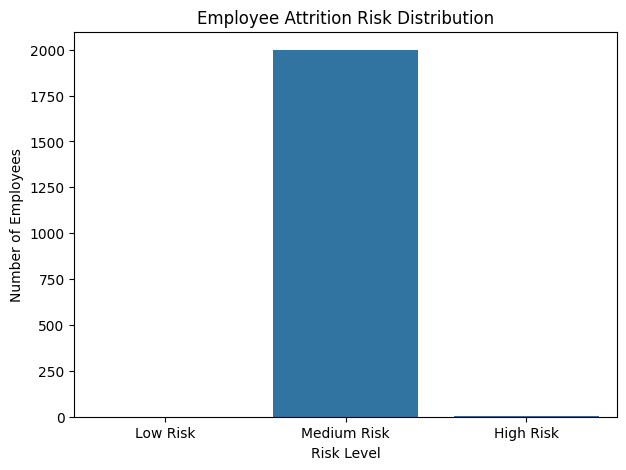


Attrition Rate by Department (%):


,Attrition Rate (%)
Department,
Finance,20.854271
IT,20.354906
Sales,19.820717
HR,19.508449
Marketing,19.362400



Department with highest observed attrition rate: Finance

Results saved successfully:
1. model_comparison.csv
2. employee_attrition_risk_predictions.csv

FINAL PROJECT SUMMARY

Dataset size:
10000 employees

Number of features:
25

Models evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Best model:
Logistic Regression


In [34]:
# ATTRITION BY OVERTIME


if "OverTime" in df.columns:

    overtime_attrition = pd.crosstab(
        df["OverTime"],
        df["Attrition"],
        normalize="index"
    ) * 100

    print("\nAttrition percentage by overtime:")
    display(overtime_attrition)

    plt.figure(figsize=(7,5))

    sns.countplot(
        data=df,
        x="OverTime",
        hue="Attrition"
    )

    plt.title("Attrition by Overtime")
    plt.xlabel("Overtime")
    plt.ylabel("Number of Employees")

    plt.show()


#  ATTRITION BY SALARY



if "MonthlyIncome" in df.columns:

    df["SalaryCategory"] = pd.qcut(
        df["MonthlyIncome"],
        q=4,
        labels=[
            "Low",
            "Medium-Low",
            "Medium-High",
            "High"
        ],
        duplicates="drop"
    )

    salary_attrition = pd.crosstab(
        df["SalaryCategory"],
        df["Attrition"],
        normalize="index"
    ) * 100

    print("\nAttrition percentage by salary category:")
    display(salary_attrition)

    plt.figure(figsize=(9,5))

    sns.countplot(
        data=df,
        x="SalaryCategory",
        hue="Attrition"
    )

    plt.title("Attrition by Salary Category")
    plt.xlabel("Salary Category")
    plt.ylabel("Number of Employees")

    plt.show()



# ATTRITION BY JOB SATISFACTION


if "JobSatisfaction" in df.columns:

    satisfaction_attrition = pd.crosstab(
        df["JobSatisfaction"],
        df["Attrition"],
        normalize="index"
    ) * 100

    print("\nAttrition percentage by Job Satisfaction:")
    display(satisfaction_attrition)

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x="JobSatisfaction",
        hue="Attrition"
    )

    plt.title("Attrition by Job Satisfaction")
    plt.xlabel("Job Satisfaction")
    plt.ylabel("Number of Employees")

    plt.show()


# NUMERICAL FEATURE CORRELATION


print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()


# CORRELATION WITH IMPORTANT VARIABLES


if "MonthlyIncome" in df.columns:

    correlations = (
        numeric_df.corr()["MonthlyIncome"]
        .sort_values(ascending=False)
    )

    print("\nCorrelation with Monthly Income:")
    print(correlations)


#CREATE TARGET VARIABLE


print("\n" + "="*70)
print("TARGET ENCODING")
print("="*70)

# Yes = 1
# No   = 0

df["Attrition_Encoded"] = (
    df["Attrition"]
    .map({
        "Yes": 1,
        "No": 0
    })
)

print(df[["Attrition", "Attrition_Encoded"]].head())

print("\nTarget distribution:")
print(df["Attrition_Encoded"].value_counts())



# 13. REMOVE TARGET FROM FEATURES

X = df.drop(
    columns=["Attrition", "Attrition_Encoded"]
)

y = df["Attrition_Encoded"]


if "SalaryCategory" in X.columns:
    X = X.drop(columns=["SalaryCategory"])



# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES


numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


#TRAIN-TEST SPLIT

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# PREPROCESSING


numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ================================================================
# 17. MODEL 1 — LOGISTIC REGRESSION
# ================================================================

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)


# ================================================================
# 18. MODEL 2 — DECISION TREE
# ================================================================

decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=6,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)


# ================================================================
# 19. MODEL 3 — RANDOM FOREST
# ================================================================

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)


# ================================================================
# 20. TRAIN MODELS
# ================================================================

print("\n" + "="*70)
print("MODEL TRAINING")
print("="*70)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

results = []

predictions = {}

for name, model in models.items():

    print("\nTraining:", name)

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    if hasattr(model, "predict_proba"):

        y_probability = model.predict_proba(
            X_test
        )[:, 1]

        roc_auc = roc_auc_score(
            y_test,
            y_probability
        )

    else:
        roc_auc = np.nan

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])


# ================================================================
# 21. MODEL COMPARISON
# ================================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

display(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    )
)


# ================================================================
# 22. CLASSIFICATION REPORTS
# ================================================================

for name, model in models.items():

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    y_pred = predictions[name]

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Stayed",
                "Left"
            ],
            zero_division=0
        )
    )


# ================================================================
# 23. CONFUSION MATRICES
# ================================================================

for name, model in models.items():

    y_pred = predictions[name]

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Stayed",
            "Left"
        ],
        yticklabels=[
            "Stayed",
            "Left"
        ]
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


# ================================================================
# 24. ROC CURVES
# ================================================================

plt.figure(figsize=(9,7))

for name, model in models.items():

    y_probability = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    auc_score = roc_auc_score(
        y_test,
        y_probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()


# ================================================================
# 25. SELECT BEST MODEL
# ================================================================

best_model_name = (
    results_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .iloc[0]["Model"]
)

best_model = models[
    best_model_name
]

print("\n" + "="*70)
print("BEST MODEL")
print("="*70)

print("Best model based on F1-score:")
print(best_model_name)


# ================================================================
# 26. FEATURE IMPORTANCE
# ================================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)


# Get transformed feature names
fitted_preprocessor = best_model.named_steps[
    "preprocessor"
]

classifier = best_model.named_steps[
    "classifier"
]

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


# ------------------------------------------------
# RANDOM FOREST / DECISION TREE
# ------------------------------------------------

if hasattr(classifier, "feature_importances_"):

    importance = classifier.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
    )

    print("\nTop 20 Important Features:")

    display(
        feature_importance_df.head(20)
    )

    plt.figure(figsize=(10,8))

    sns.barplot(
        data=feature_importance_df.head(20),
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"Top 20 Feature Importance - {best_model_name}"
    )

    plt.show()


# ================================================================
# 27. LOGISTIC REGRESSION COEFFICIENTS
# ================================================================

if "Logistic Regression" in models:

    lr_model = models[
        "Logistic Regression"
    ]

    lr_classifier = lr_model.named_steps[
        "classifier"
    ]

    lr_preprocessor = lr_model.named_steps[
        "preprocessor"
    ]

    lr_feature_names = (
        lr_preprocessor
        .get_feature_names_out()
    )

    coefficients = lr_classifier.coef_[0]

    coefficient_df = pd.DataFrame({
        "Feature": lr_feature_names,
        "Coefficient": coefficients
    })

    coefficient_df["Absolute_Coefficient"] = (
        coefficient_df["Coefficient"].abs()
    )

    coefficient_df = (
        coefficient_df
        .sort_values(
            by="Absolute_Coefficient",
            ascending=False
        )
    )

    print("\nMost influential Logistic Regression features:")

    display(
        coefficient_df.head(20)
    )


# ================================================================
# 28. HIGH-RISK EMPLOYEE IDENTIFICATION
# ================================================================

print("\n" + "="*70)
print("HIGH-RISK EMPLOYEE IDENTIFICATION")
print("="*70)

# Use best model probabilities

risk_probability = best_model.predict_proba(
    X_test
)[:, 1]

risk_df = X_test.copy()

risk_df["Actual_Attrition"] = y_test.values

risk_df["Attrition_Risk_Probability"] = (
    risk_probability
)

risk_df["Risk_Level"] = pd.cut(
    risk_probability,
    bins=[
        0,
        0.30,
        0.60,
        1.00
    ],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

risk_df = risk_df.sort_values(
    by="Attrition_Risk_Probability",
    ascending=False
)

print("\nTop 20 high-risk employees:")

display(
    risk_df[
        [
            "Attrition_Risk_Probability",
            "Risk_Level"
        ]
    ].head(20)
)


# RISK DISTRIBUTION


print("\nRisk Distribution:")

print(
    risk_df["Risk_Level"]
    .value_counts()
)


plt.figure(figsize=(7,5))

sns.countplot(
    data=risk_df,
    x="Risk_Level",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Employee Attrition Risk Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Number of Employees")

plt.show()




#  AUTOMATIC DEPARTMENT INSIGHT


if "Department" in df.columns:

    department_rate = (
        df.groupby("Department")["Attrition_Encoded"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print("\nAttrition Rate by Department (%):")

    display(
        department_rate
        .to_frame("Attrition Rate (%)")
    )

    highest_department = (
        department_rate.index[0]
    )

    print(
        f"\nDepartment with highest observed attrition rate: "
        f"{highest_department}"
    )


# ================================================================
# 32. AUTOMATIC OVERTIME INSIGHT
# ================================================================

if "OverTime" in df.columns:

    overtime_rate = (
        df.groupby("OverTime")["Attrition_Encoded"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print("\nAttrition Rate by Overtime (%):")

    display(
        overtime_rate
        .to_frame("Attrition Rate (%)")
    )


# ================================================================
# 33. SAVE RESULTS
# ================================================================

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

risk_df.to_csv(
    "employee_attrition_risk_predictions.csv",
    index=False
)

print("\nResults saved successfully:")
print("1. model_comparison.csv")
print("2. employee_attrition_risk_predictions.csv")


# 34. FINAL SUMMARY


print("\n" + "="*70)
print("FINAL PROJECT SUMMARY")
print("="*70)

print(
    f"""
Dataset size:
{df.shape[0]} employees

Number of features:
{X.shape[1]}

Models evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Best model:
{best_model_name}"""
    )
